# XGBoost

We do the following:

1. **Sanity check**: vanilla XGBoost on all tiers, just to verify we're not regressing vs Random Forest
2. **Hyperparameter tuning**: RandomizedSearchCV over 30 configs x 5-fold CV, optimizing log loss
3. **Calibration**: Platt scaling and isotonic regression on the tuned XGBoost, plus calibration curves comparing LR / RF / XGBoost raw / XGBoost+Platt / XGBoost+Isotonic
4. **Feature importance**: gain-based importance for the tuned XGBoost


## 1. Setup

In [1]:
import os, sys, time, warnings, pickle
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

from src.features import build_features, TIER_COLUMNS, feature_set
from src.models import load_features, split, train_eval, evaluate

sns.set_style('whitegrid'); plt.rcParams['figure.dpi'] = 100

## 2. Loading features

In [2]:
df = load_features()
train, test = split(df)
print(f'Train: {len(train):,}  Test: {len(test):,}  base rate: {df["goal"].mean():.3f}')

T1 = feature_set('tier1')
T12 = feature_set('tier1', 'tier2')
T123 = feature_set('tier1', 'tier2', 'tier3')
T1234 = feature_set('tier1', 'tier2', 'tier3', 'tier4')
T12345 = feature_set('tier1', 'tier2', 'tier3', 'tier4', 'tier5')
print(f'Tier 1+2+3+4 : {len(T1234)} features')
print(f'Tier 1+2+3+4+5 (all): {len(T12345)} features')

Train: 69,250  Test: 17,313  base rate: 0.101
Tier 1+2+3+4 : 47 features
Tier 1+2+3+4+5 (all): 57 features


## 3. Plain XGBoost on all features

We must confirm whether a default-config XGBoost is at least as good as our best Random Forest from the baselines.


In [3]:
def make_xgb(**kw):
    defaults = dict(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42,
        verbosity=0,
    )
    defaults.update(kw)
    return xgb.XGBClassifier(**defaults)

results = []

t0 = time.time()
results.append(train_eval(make_xgb(), train, test, T12345, name='XGBoost (vanilla)', tier='Tier 1+2+3+4+5 (all)'))
print(f'Vanilla fit in {time.time()-t0:.1f}s')
pd.DataFrame(results)

Vanilla fit in 2.7s


,model,tier,n_features,auc_roc,log_loss,brier
0,XGBoost (vanilla),Tier 1+2+3+4+5 (all),57,0.810799,0.259089,0.073501


## 4. Hyperparameter tuning

We use RandomizedSearchCV with 30 random configs × 5-fold CV, scored on neg_log_loss.

- `n_estimators` from {100, 200, 300}: shallow boosters with many small trees usually beat deep boosters with few trees on tabular data
- `max_depth` from {3, 4, 5, 6}: regularization knob; deeper = more interactions but higher variance
- `learning_rate` from {0.05, 0.1}: standard "small but not tiny" range
- `subsample`, `colsample_bytree`: stochastic regularization
- `min_child_weight`, `gamma`: pruning regularization

In [4]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1],
}

base = make_xgb()
search = RandomizedSearchCV(
    base,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_log_loss',
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit=True,
)

t0 = time.time()
search.fit(train[T12345], train['goal'])
print(f'\nTuning finished in {(time.time()-t0)/60:.1f} min')
print(f'Best CV log loss: {-search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning finished in 2.9 min
Best CV log loss: 0.2587
Best params: {'subsample': 0.85, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}


In [5]:
tuned = search.best_estimator_
proba_test = tuned.predict_proba(test[T12345])[:, 1]
m = evaluate(test['goal'], proba_test)
results.append({'model': 'XGBoost (tuned)', 'tier': 'Tier 1+2+3+4+5 (all)', 'n_features': len(T12345), **m})
print(pd.DataFrame(results).to_string(index=False))

            model                 tier  n_features  auc_roc  log_loss    brier
XGBoost (vanilla) Tier 1+2+3+4+5 (all)          57 0.810799  0.259089 0.073501
  XGBoost (tuned) Tier 1+2+3+4+5 (all)          57 0.812348  0.258216 0.073375


## 5. Tier ablation under tuned XGBoost

We see how each tier addition affects the results. This will help us decide the best model


In [6]:
best_params = search.best_params_

for tier_cols, tier_name in [
    (T1, 'Tier 1 only (geometry)'),
    (T12, 'Tier 1+2'),
    (T123, 'Tier 1+2+3 (GK)'),
    (T1234, 'Tier 1+2+3+4 (freeze frame)'),
]:
    model = make_xgb(**best_params)
    row = train_eval(model, train, test, tier_cols, name='XGBoost (tuned)', tier=tier_name)
    results.append(row)

pd.DataFrame(results).tail(5)

,model,tier,n_features,auc_roc,log_loss,brier
1,XGBoost (tuned),Tier 1+2+3+4+5 (all),57,0.812348,0.258216,0.073375
2,XGBoost (tuned),Tier 1 only (geometry),2,0.739224,0.290609,0.082639
3,XGBoost (tuned),Tier 1+2,32,0.787294,0.271997,0.077497
4,XGBoost (tuned),Tier 1+2+3 (GK),39,0.802340,0.264298,0.075276
5,XGBoost (tuned),Tier 1+2+3+4 (freeze frame),47,0.811184,0.259274,0.073757


## 6. Platt and Isotonic Calibration

Tree-based ensembles tend to push probabilities away from 0 and 1, producing miscalibrated outputs. We test two standard post-hoc fixes:

- **Platt scaling** (`method='sigmoid'`): fits a 1-parameter logistic on the model outputs. Best when miscalibration follows a sigmoid pattern.
- **Isotonic regression** (`method='isotonic'`): non-parametric step function. More flexible but needs more data.

In [7]:
base_for_cal = make_xgb(**best_params)

t0 = time.time()
cal_platt = CalibratedClassifierCV(base_for_cal, method='sigmoid',  cv=5, n_jobs=1)
cal_platt.fit(train[T12345], train['goal'])
print(f'Platt calibration fit in {(time.time()-t0)/60:.1f} min')

t0 = time.time()
cal_iso = CalibratedClassifierCV(base_for_cal, method='isotonic', cv=5, n_jobs=1)
cal_iso.fit(train[T12345], train['goal'])
print(f'Isotonic calibration fit in {(time.time()-t0)/60:.1f} min')

proba_platt = cal_platt.predict_proba(test[T12345])[:, 1]
proba_iso = cal_iso.predict_proba(test[T12345])[:, 1]

results.append({'model': 'XGBoost + Platt',    'tier': 'Tier 1+2+3+4+5 (all)', 'n_features': len(T12345), **evaluate(test['goal'], proba_platt)})
results.append({'model': 'XGBoost + Isotonic', 'tier': 'Tier 1+2+3+4+5 (all)', 'n_features': len(T12345), **evaluate(test['goal'], proba_iso)})

pd.DataFrame(results).tail(3)

Platt calibration fit in 0.1 min
Isotonic calibration fit in 0.1 min


,model,tier,n_features,auc_roc,log_loss,brier
5,XGBoost (tuned),Tier 1+2+3+4 (freeze frame),47,0.811184,0.259274,0.073757
6,XGBoost + Platt,Tier 1+2+3+4+5 (all),57,0.812615,0.264262,0.074353
7,XGBoost + Isotonic,Tier 1+2+3+4+5 (all),57,0.812781,0.258701,0.073524


**Interpreting these rows:** if AUC stays roughly constant across raw
and calibrated versions but **Brier and log loss drop**, the model was
miscalibrated and the fix worked. AUC is rank-based so it doesn't move when
probabilities are monotonically rescaled. The Brier / log loss improvement
is real evidence of calibration.


## 7. Calibration curves


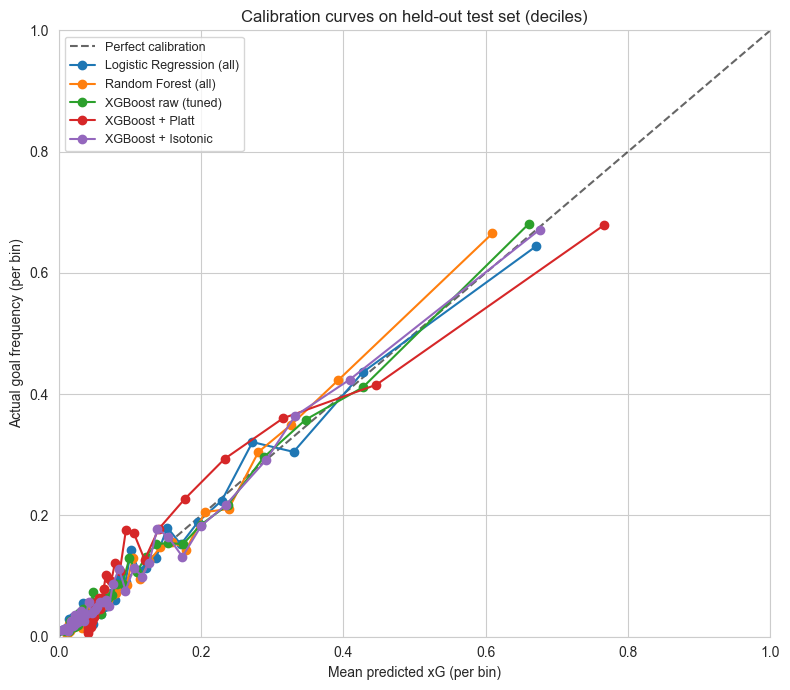

In [11]:
lr = Pipeline([('scale', StandardScaler()), ('clf', LogisticRegression(C=1.0, max_iter=2000))])
lr.fit(train[T12345], train['goal'])
proba_lr = lr.predict_proba(test[T12345])[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf.fit(train[T12345], train['goal'])
proba_rf = rf.predict_proba(test[T12345])[:, 1]

proba_xgb_raw = proba_test

y_test = test['goal'].values
curves = {
    'Logistic Regression (all)' : proba_lr,
    'Random Forest (all)': proba_rf,
    'XGBoost raw (tuned)': proba_xgb_raw,
    'XGBoost + Platt': proba_platt,
    'XGBoost + Isotonic': proba_iso,
}

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Perfect calibration')

for name, p in curves.items():
    prob_true, prob_pred = calibration_curve(y_test, p, n_bins=40, strategy='quantile')
    ax.plot(prob_pred, prob_true, marker='o', label=name)

ax.set_xlabel('Mean predicted xG (per bin)')
ax.set_ylabel('Actual goal frequency (per bin)')
ax.set_title('Calibration curves on held-out test set (deciles)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/04b_calibration_curves.png', dpi=140, bbox_inches='tight')
plt.show()


## 8. Feature importance (gain-based)


Top 15 features by gain:
gk_distance_to_shot             159.27
header_distance                  76.18
available_goal_angle             72.49
defenders_blocked_angle          49.72
angle_to_goal                    47.98
available_goal_fraction          37.18
kp_through_ball                  36.02
shot_gk_angle                    27.51
stype_open_play                  22.84
gk_distance_to_goal_line         21.31
n_players_in_frame               19.68
bp_head                          18.94
stype_free_kick                  18.37
kp_distance_to_goal              16.96
distance_to_nearest_defender     16.39
dtype: float64


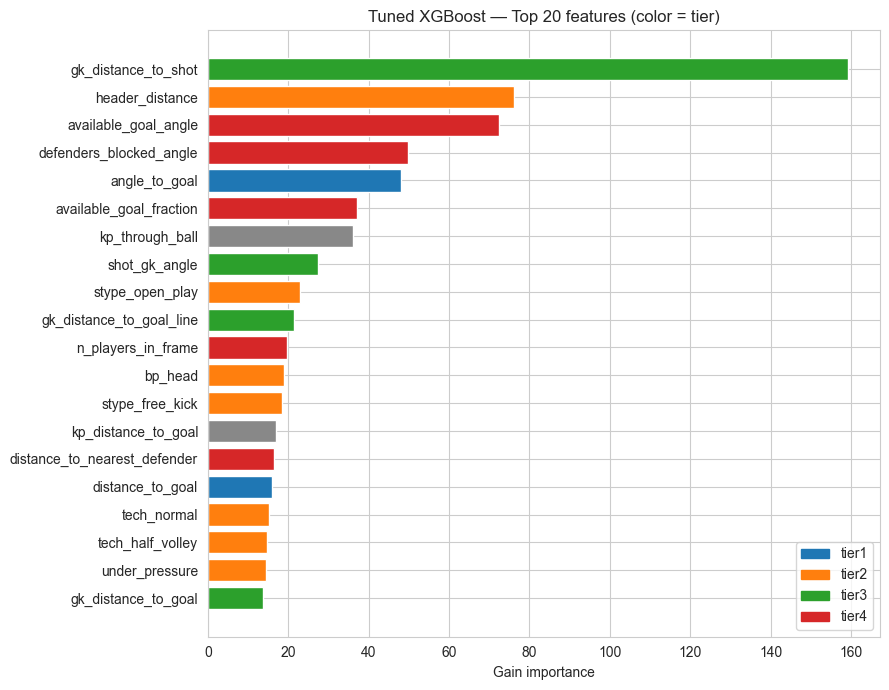

In [9]:
booster = tuned.get_booster()
imp = booster.get_score(importance_type='gain')
imp_series = pd.Series(imp).sort_values(ascending=False)

print(f'Top 15 features by gain:')
print(imp_series.head(15).round(2))

top = imp_series.head(20)
fig, ax = plt.subplots(figsize=(9, 7))

def tier_of(col):
    for t in ['tier4', 'tier3', 'tier2', 'tier1']:
        if col in TIER_COLUMNS[t]:
            return t
    return 'other'

colors = {'tier1': '#1f77b4', 'tier2': '#ff7f0e',
          'tier3': '#2ca02c', 'tier4': '#d62728', 'other': '#888'}
bar_colors = [colors[tier_of(c)] for c in top.index]

ax.barh(top.index[::-1], top.values[::-1], color=bar_colors[::-1])
ax.set_xlabel('Gain importance')
ax.set_title('Tuned XGBoost — Top 20 features (color = tier)')

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=t) for t, c in colors.items() if t != 'other']
ax.legend(handles=patches, loc='lower right')

plt.tight_layout()
plt.savefig('figures/04b_feature_importance.png', dpi=140, bbox_inches='tight')
plt.show()

## 9. Saving models

In [10]:
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

with open('models/xgboost_tuned.pkl', 'wb') as f:
    pickle.dump(tuned, f)
with open('models/xgboost_isotonic.pkl', 'wb') as f:
    pickle.dump(cal_iso, f)
print('Saved tuned + isotonic XGBoost models.')


xgb_results = pd.DataFrame(results)
xgb_results.to_csv('results/xgboost.csv', index=False)
print('Saved results/xgboost.csv')

baselines = pd.read_csv('results/baselines.csv')
all_results = pd.concat([baselines, xgb_results], ignore_index=True)
all_results.to_csv('results/all_models.csv', index=False)
print('Saved results/all_models.csv')

print('\n============== Final combined leaderboard (sorted by log loss) ==============')
print(all_results.sort_values('log_loss').to_string(index=False,
    formatters={'auc_roc': '{:.4f}'.format,
                'log_loss': '{:.4f}'.format,
                'brier': '{:.4f}'.format}))

Saved tuned + isotonic XGBoost models.
Saved results/xgboost.csv
Saved results/all_models.csv

============== Final combined leaderboard (sorted by log loss) ==============
              model                        tier  n_features auc_roc log_loss  brier
    XGBoost (tuned)        Tier 1+2+3+4+5 (all)          57  0.8123   0.2582 0.0734
 XGBoost + Isotonic        Tier 1+2+3+4+5 (all)          57  0.8128   0.2587 0.0735
  XGBoost (vanilla)        Tier 1+2+3+4+5 (all)          57  0.8108   0.2591 0.0735
    XGBoost (tuned) Tier 1+2+3+4 (freeze frame)          47  0.8112   0.2593 0.0738
      Random Forest        Tier 1+2+3+4+5 (all)          57  0.8101   0.2596 0.0738
      Random Forest Tier 1+2+3+4 (freeze frame)          47  0.8094   0.2603 0.0740
Logistic Regression        Tier 1+2+3+4+5 (all)          61  0.8045   0.2625 0.0744
Logistic Regression Tier 1+2+3+4 (freeze frame)          51  0.8026   0.2636 0.0747
    XGBoost + Platt        Tier 1+2+3+4+5 (all)          57  0.8126   0